In [4]:
import numpy as np
import tables_io

import matplotlib.pyplot as plt
plt.style.use("/global/homes/s/sajkov/umap_nz_cal.mplstyle")

In [5]:
date = "07Jul26_test2"
outputs_directory = f"/pscratch/sd/s/sajkov/analysis_pipeline/runs/{date}"

In [8]:
REDSHIFTS_WideFastDeep     = np.load(f"{outputs_directory}/TRUEREDSHIFTS_WideFastDeep.npy")
PHOTOZS_estimated_wSpecZs  = np.load(f"{outputs_directory}/PHOTOZS_flexZBoost_specZs.npy")
PHOTOZS_estimated_wPhotoZs = np.load(f"{outputs_directory}/PHOTOZS_flexZBoost_photoZs.npy")

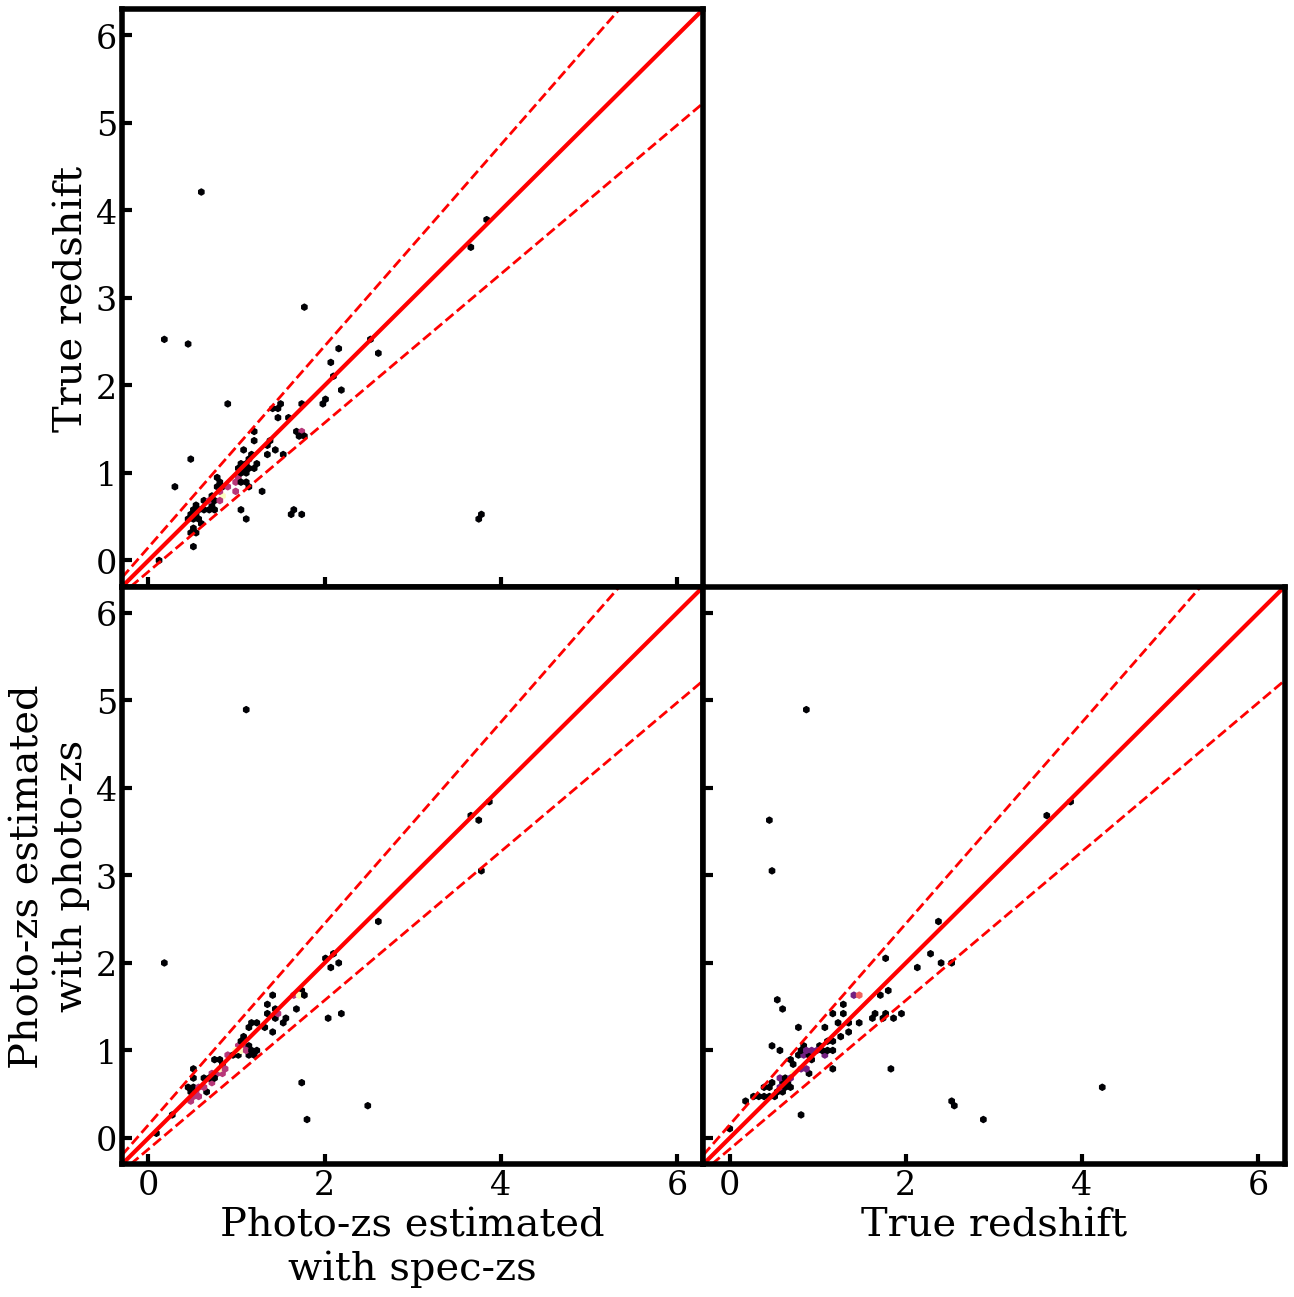

In [9]:
fig = plt.figure(figsize = (15, 15))
axs = fig.subplots(2, 2, sharex = True, sharey = True)

hexbin_props = dict(
    mincnt = 1,
    extent = [0, 6, 0, 6]
)

ax_bl = axs[1, 0]
ax_bl.hexbin(PHOTOZS_estimated_wSpecZs[::10], PHOTOZS_estimated_wPhotoZs[::10], **hexbin_props)
ax_bl.set_xlabel("Photo-zs estimated\nwith spec-zs")
ax_bl.set_ylabel("Photo-zs estimated\nwith photo-zs")
ax_bl.axline((0, 0), slope = 1, color = "red")
ax_bl.axline((0, .15), slope = 1.15, color = "red", linestyle = "--", linewidth = 2)
ax_bl.axline((.15, 0), slope = .85, color = "red", linestyle = "--", linewidth = 2)


ax_tl = axs[0, 0]
ax_tl.hexbin(PHOTOZS_estimated_wSpecZs[::10], REDSHIFTS_WideFastDeep[::10], **hexbin_props)
ax_tl.set_ylabel("True redshift")
ax_tl.axline((0, 0), slope = 1, color = "red")
ax_tl.axline((0, .15), slope = 1.15, color = "red", linestyle = "--", linewidth = 2)
ax_tl.axline((.15, 0), slope = .85, color = "red", linestyle = "--", linewidth = 2)

ax_br = axs[1, 1]
ax_br.hexbin(REDSHIFTS_WideFastDeep[::10], PHOTOZS_estimated_wPhotoZs[::10], **hexbin_props)
ax_br.set_xlabel("True redshift")
ax_br.axline((0, 0), slope = 1, color = "red")
ax_br.axline((0, .15), slope = 1.15, color = "red", linestyle = "--", linewidth = 2)
ax_br.axline((.15, 0), slope = .85, color = "red", linestyle = "--", linewidth = 2)

axs[0, 1].remove()

fig.subplots_adjust(hspace = 0, wspace = 0)
# fig.savefig(f"{outputs_directory}/comparison_plot.png", dpi = 150, bbox_inches = "tight")

In [6]:
PHOTOMETRY_DeepField_noisy    = tables_io.read("/pscratch/sd/s/sajkov/analysis_pipeline/runs/08Jul26/PHOTOMETRY_DeepField_noisy_08Jul26.pq")
PHOTOMETRY_WideFastDeep_noisy = tables_io.read("/pscratch/sd/s/sajkov/analysis_pipeline/runs/08Jul26/PHOTOMETRY_WideFastDeep_noisy_08Jul26.pq")
PHOTOZS_DeepField_lePhare     = tables_io.read("/pscratch/sd/s/sajkov/analysis_pipeline/runs/08Jul26/PHOTOZS_DeepField_lePhare_08Jul26.pq")['photo-z']
REDSHIFTS_DeepField           = np.load("/pscratch/sd/s/sajkov/analysis_pipeline/runs/08Jul26/TRUEREDSHIFTS_DeepField.npy")

column_list None
column_list None
column_list None


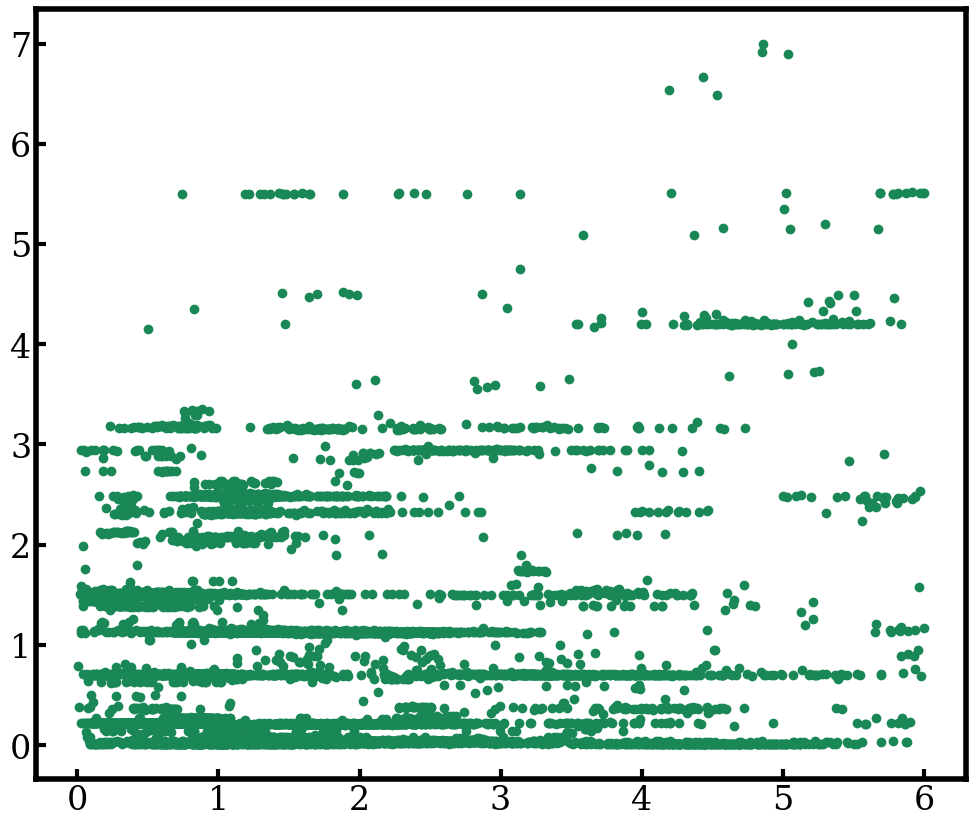

In [7]:
fig = plt.figure()
ax  = fig.add_subplot()

ax.scatter(REDSHIFTS_DeepField, PHOTOZS_DeepField_lePhare)

(array([4967., 2349., 1016., 1069.,  396.,   60.,   94.,   43.,    0.,
           6.]),
 array([0.01      , 0.70848886, 1.40697772, 2.10546658, 2.80395544,
        3.5024443 , 4.20093316, 4.89942203, 5.59791089, 6.29639975,
        6.99488861]),
 <BarContainer object of 10 artists>)

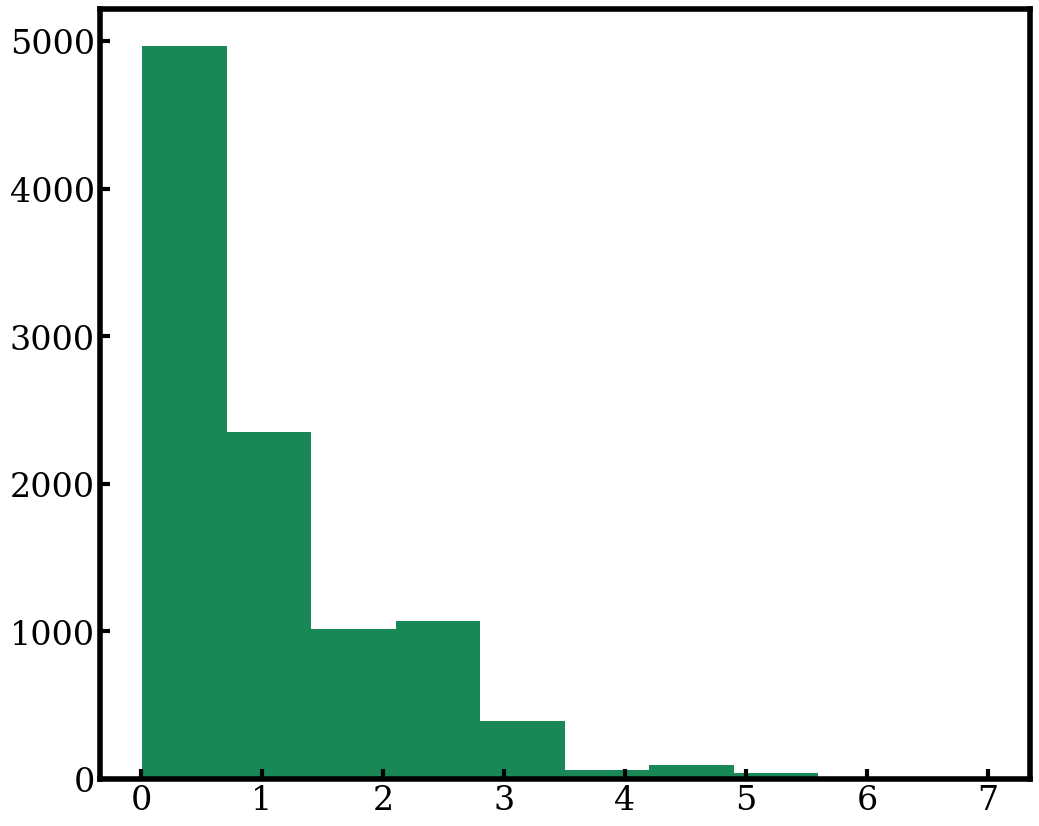

In [8]:
fig = plt.figure()
ax = fig.add_subplot()
ax.hist(PHOTOZS_DeepField_lePhare)